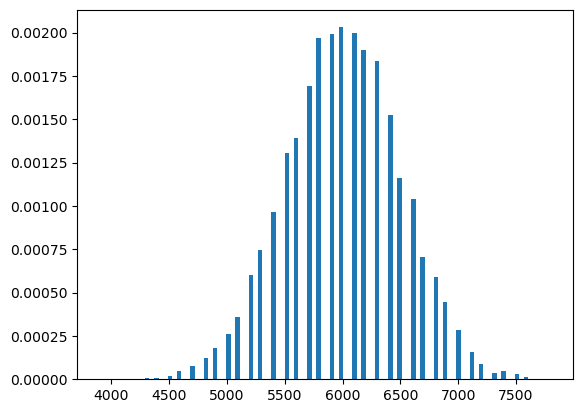

In [1]:
import matplotlib.pyplot as plt
import numpy as np
# multinomial distribution
plt.figure()
distro = np.random.binomial(100, .6, 10000)/0.01
plt.hist(distro, 100 , density=True)
plt.show()

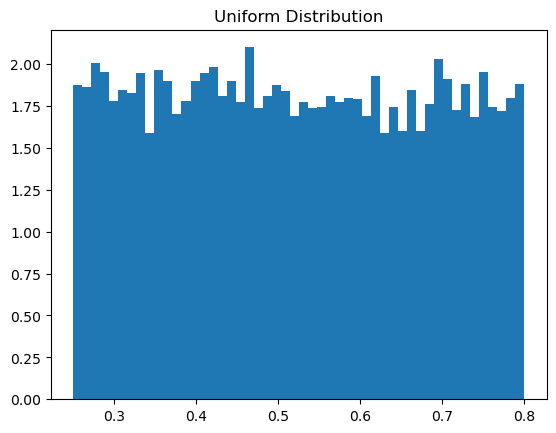

In [2]:
# Uniform distribution
plt.figure()
uniform_low=0.25
uniform_high=0.8
uniform = np.random.uniform(uniform_low, uniform_high, 10000)
plt.hist(uniform, 50, density=True)
plt.title('Uniform Distribution')
plt.show()

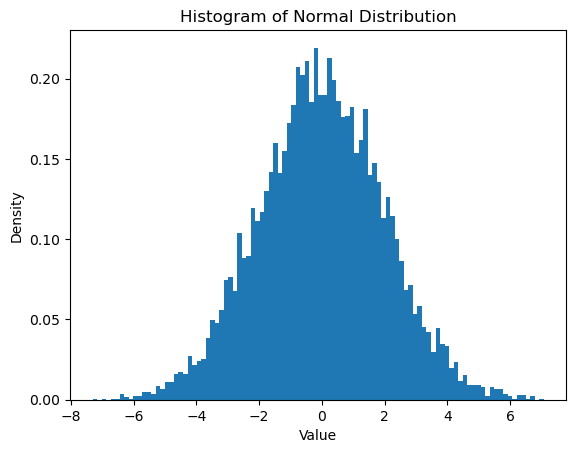

In [3]:
# Normal Distribution
mu = 0.0
sigma = 2.0
distro = np.random.normal(mu,sigma,10000)
plt.hist(distro, 100, density = True)
plt.title('Histogram of Normal Distribution')
plt.xlabel('Value')
plt.ylabel('Density')
plt.show()

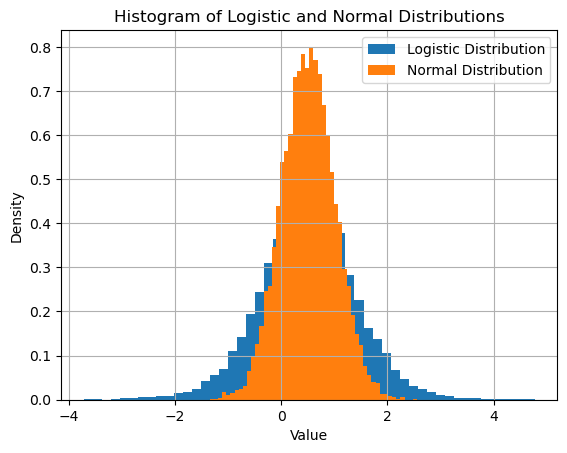

In [4]:
# Logistic distribution
mu=0.5
sigma=0.5
distro2 = np.random.logistic(mu, sigma, 10000)
plt.hist(distro2, 50, density=True)
distro = np.random.normal(mu, sigma, 10000)
plt.hist(distro, 50, density=True)
plt.title('Histogram of Logistic and Normal Distributions')
plt.xlabel('Value')
plt.ylabel('Density')
plt.legend(['Logistic Distribution', 'Normal Distribution'])
plt.grid(True)
plt.show()

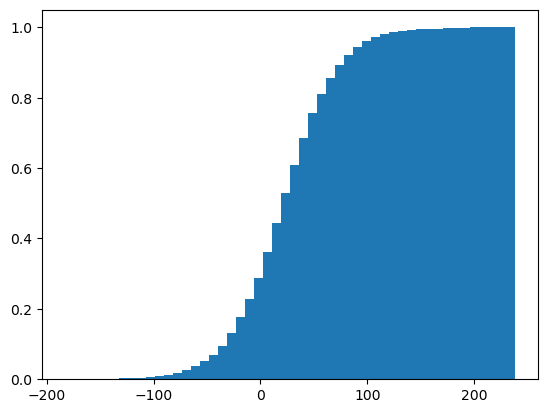

In [5]:
# CDF of logistic Distribution
plt.figure()
logistic_cumulative = np.random.logistic(mu, sigma, 10000)/0.02
plt.hist(logistic_cumulative, 50, density=True, cumulative=True)
plt.show()

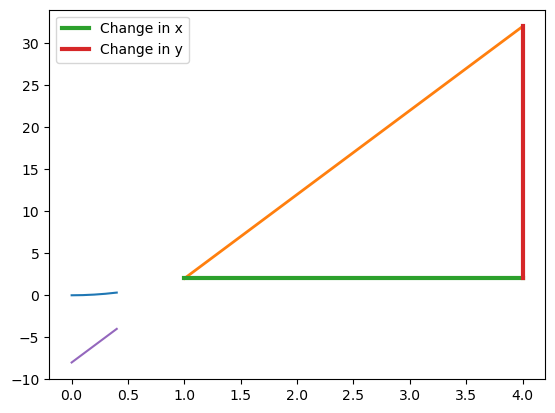

In [6]:
# Sliding on the slope
%matplotlib inline

def quadratic(var):
    return 2*(var**2)
x=np.arange(0,.5,.1)
plt.plot(x,quadratic(x))
plt.plot([1,4], [quadratic(1), quadratic(4)],  linewidth=2.0)
plt.plot([1,4], [quadratic(1), quadratic(1)],  linewidth=3.0,
label="Change in x")
plt.plot([4,4], [quadratic(1), quadratic(4)],  linewidth=3.0,
label="Change in y")
plt.legend()
plt.plot (x, 10*x -8 )
plt.show()

In [7]:
# instanteneous change
initital_delta = 0.1
x1 = 1
for power in range(1, 6):
    delta = pow(initital_delta, power)
    derivative_approx = (quadratic(x1+delta) - quadratic(x1))/((x1+delta) - x1)
    print(f"Power: {power}, Delta: {delta}, Derivative Approximation: {derivative_approx:.4f}")

Power: 1, Delta: 0.1, Derivative Approximation: 4.2000
Power: 2, Delta: 0.010000000000000002, Derivative Approximation: 4.0200
Power: 3, Delta: 0.0010000000000000002, Derivative Approximation: 4.0020
Power: 4, Delta: 0.00010000000000000002, Derivative Approximation: 4.0002
Power: 5, Delta: 1.0000000000000003e-05, Derivative Approximation: 4.0000


In [8]:
%pip install scipy

Defaulting to user installation because normal site-packages is not writeableNote: you may need to restart the kernel to use updated packages.



### Working with 2D data

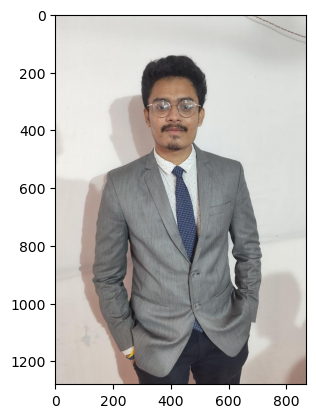

In [9]:
# Working with 2D data
import scipy.misc
import imageio.v2 as imageio
testimg = imageio.imread('virajphoto.jpg')
plt.imshow(testimg)
plt.show()

In [10]:
testimg.shape

(1280, 869, 3)

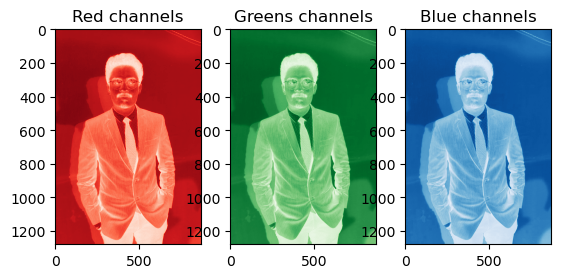

In [11]:
# separating color channels
plt.subplot(131)
plt.imshow(testimg[:,:,0], cmap='Reds')
plt.title("Red channels")
plt.subplot(132)
plt.imshow(testimg[:,:,1], cmap='Greens')
plt.title("Greens channels")
plt.subplot(133)
plt.imshow(testimg[:,:,2], cmap='Blues')
plt.title("Blue channels")

plt.show()

## OHE from scratch

In [12]:

def get_one_hot(input_vec):
    result = []
    for i in input_vec:
        newval = np.zeros(max(input_vec))
        newval.itemset(i-1,1)
        result.append(newval)
    return result

# get_one_hot([1,5,2,4,3])
get_one_hot([1,3,2,4])

[array([1., 0., 0., 0.]),
 array([0., 0., 1., 0.]),
 array([0., 1., 0., 0.]),
 array([0., 0., 0., 1.])]

In [14]:
# never initialize the weights to 0.
# it will cause the neurons to learn the same features
# and the model will not learn anything.

mu, sigma = 0.0, 1.0
dist = np.random.normal(mu, sigma,10)
print(dist)


[ 0.88467943 -0.46620136 -0.80474266  0.07164485 -0.48372     1.78763316
  0.65153956 -0.3831366   0.06765027  0.30065478]


[[0 1 1 0 0 0 0 0]
 [0 0 0 0 1 0 0 0]
 [0 1 0 0 0 0 1 0]
 [0 0 0 1 0 1 0 0]
 [0 0 0 0 3 0 0 0]
 [0 0 0 1 0 1 0 0]
 [0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 2]]


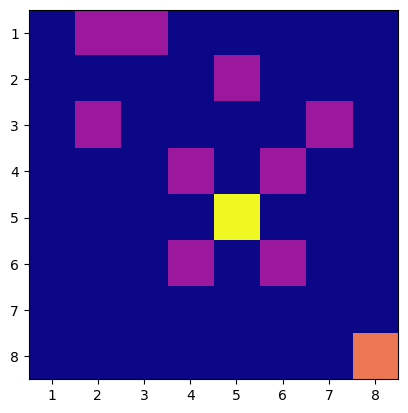

In [15]:
#CM
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import numpy as np
y_true = [8,5,6,8,5,3,1,6,4,2,5,3,1,4]
y_pred = [8,5,6,8,5,2,3,4,4,5,5,7,2,6]
y = confusion_matrix(y_true, y_pred)
print(y)
plt.imshow(confusion_matrix(y_true, y_pred), interpolation='nearest',
cmap='plasma')
plt.xticks(np.arange(0,8), np.arange(1,9))
plt.yticks(np.arange(0,8), np.arange(1,9))
plt.show()